# Claims Audit

Popular numerical claims about Quranic word counts — "*dunya* and *akhira* each occur 115
times", "*yawm* occurs 365 times", "sea is to land as 32 : 13 = 71% : 29%" — circulate widely
but are almost never published with a counting method. This notebook collects the claims and
evaluates **every claim against every uniform counting method** in the project's grid, so that
each one gets an explicit, reproducible verdict:

- **holds (lemma)** — reproduces at the headline lemma level;
- **holds (uniform)** — reproduces under some uniform method (the *same* selection applied to
  both sides of a pair);
- **mixed methods only** — each side reproduces, but only under a *different* method per side;
- **one side only** — one claimed number reproduces under some method, the other under none;
- **does not hold** — no method examined reproduces the claim.

**Claim sources.** The claims were collected (2026-06-11) from the three lineages that copy
from each other: (a) ʿAbd al-Razzāq Nawfal, *al-Iʿjāz al-ʿAdadī lil-Qurʾān al-Karīm* (the
founding 1960s–70s work: dunya/akhira, angels/devils, qul/qālū, the ratio pairs); (b) the viral
"Dr. Tariq Al-Suwaidan" email/pamphlet list (~2000s: ḥayāt/mawt 145, ṣāliḥāt/sayyiʾāt 167,
yawm 365, shahr 12); (c) Harun Yahya's *Word Repetitions in the Qur'an* chapter (plant/tree,
jazāʾ/maghfira, zakāt/baraka). Per-claim sources are recorded in the claims registry below.
Where a counting convention is stated at all, it is usually by critics reverse-engineering it
(e.g. IslamQA fatwa 69741, quoting Fahd al-Rūmī; WikiIslam's per-pair critique pages) — those
reverse-engineered conventions appear in the method grid as `singular definite` and
`no pron suffix`.

**Honesty caveats, stated up front.**

1. *Look-elsewhere effect*: each claim is tested against ~11 methods, so a single match is weak
   evidence of anything — with this many selections available, some number will often hit. The
   audit therefore reports *which and how many* methods agree, never just "found a match".
2. Two methods (`singular definite`, `no pron suffix`) were added to the grid *because* critics
   identified them as the conventions behind specific claims. They are uniform (applied
   identically to both sides of every claim), but their inclusion is itself claim-driven.
3. The audit evaluates **counts**, not inferences. Where a count reproduces (e.g. sea 32 :
   land 13), any further claim built on it (e.g. "= Earth's surface water ratio") is a separate,
   non-arithmetic assertion that a word-frequency table can neither confirm nor refute.
4. Words outside the project's 38-word validated set (e.g. nafʿ, fasād, lisān) are counted with
   the same parser and corpus snapshot, but have **not** been token-validated against the
   Uthmani text the way the 38 words were (README §4).

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
from src.parser import load_morphology, load_prefixes, load_pron_suffixes
from src.buckwalter import bw_to_arabic

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_rows", 400)
pd.set_option("display.width", 250)

df = load_morphology()
DEFINITE = load_prefixes()          # (chapter, verse, word) with the definite article Al+
PRON_SUFFIXED = load_pron_suffixes()  # (chapter, verse, word) with an attached pronoun suffix

assert len(df) == 77915
assert len(PRON_SUFFIXED) == 20146
print(f"STEM entries: {len(df):,};  definite words: {len(DEFINITE):,};  "
      f"pronoun-suffixed words: {len(PRON_SUFFIXED):,}")

STEM entries: 77,915;  definite words: 8,377;  pronoun-suffixed words: 20,146


## 1. Counting methods

The grid from notebook 03 (lemma / lemma+variants / number / root) plus the two claim-driven
conventions and two token-level selections:

| Method | What it counts |
|---|---|
| `lemma` | exact lemma match, all grammatical forms (the project's headline method) |
| `lemma+variants` | plus the variant selectors declared in notebook 03 (irregular plurals, variant nouns) |
| `singular` / `dual` / `plural` / `plural+dual` | lemma match split by grammatical number |
| `singular definite` | singular **and** carrying the definite article (al-) |
| `lemma, no pron suffix` | lemma match, excluding words with an attached pronoun (*yawmu-hum* "their day") |
| `singular, no pron suffix` | both restrictions |
| `root, all` / `root, nominal` | everything sharing the root / its nominal subset (N, ADJ, PN, T) |
| `exact form(s)` | a specific surface form (only for claims about a specific form, e.g. أبرار) |
| `grammatical selection` | a stated grammatical category (only where the claim names one, e.g. *qul* = imperative) |

A method that does not apply to a side (no root for proper nouns, no declared forms, …)
is reported as `—` and can neither support nor refute a claim.

In [2]:
SG = df.NUMBER.isna() | (df.NUMBER == "S")   # unmarked number = singular (README 3.2)
LOC = pd.Series(list(zip(df.chapter, df.verse, df.word)), index=df.index)
IS_DEF = LOC.isin(DEFINITE)
HAS_PRON = LOC.isin(PRON_SUFFIXED)
POS_NOMINAL = ["N", "ADJ", "PN", "T"]


def selector_mask(lem, pos=None, number=None):
    m = df.LEM == lem
    if pos is not None:
        m &= df.POS == pos
    if number is not None:
        m &= df.NUMBER == number
    return m


def side_mask(side, variants=False):
    if not side.get("lemmas"):
        return None
    m = df.LEM.isin(side["lemmas"])
    if side.get("gender"):
        m &= df.PGN.str.contains(side["gender"], na=False)
    if variants:
        for v in side.get("variants", []):
            m |= selector_mask(*v)
    return m


def count(side, method):
    """Count one claim side under one named method; None = not applicable."""
    m = side_mask(side)
    root = side.get("root")
    if method == "lemma":
        return None if m is None else int(m.sum())
    if method == "lemma+variants":
        if m is None or not side.get("variants"):
            return None
        return int(side_mask(side, variants=True).sum())
    if method == "singular":
        return None if m is None else int((m & SG).sum())
    if method == "dual":
        return None if m is None else int((m & (df.NUMBER == "D")).sum())
    if method == "plural":
        return None if m is None else int((m & (df.NUMBER == "P")).sum())
    if method == "plural+dual":
        return None if m is None else int((m & df.NUMBER.isin(["D", "P"])).sum())
    if method == "singular definite":
        return None if m is None else int((m & SG & IS_DEF).sum())
    if method == "lemma, no pron suffix":
        return None if m is None else int((m & ~HAS_PRON).sum())
    if method == "singular, no pron suffix":
        return None if m is None else int((m & SG & ~HAS_PRON).sum())
    if method == "root, all":
        return None if not root else int((df.ROOT == root).sum())
    if method == "root, nominal":
        return None if not root else int(((df.ROOT == root) & df.POS.isin(POS_NOMINAL)).sum())
    if method == "exact form(s)":
        return None if not side.get("forms") else int(df.form.isin(side["forms"]).sum())
    if method == "grammatical selection":
        return None if not side.get("custom") else int(side["custom"]())
    raise ValueError(method)


METHODS = ["lemma", "lemma+variants", "singular", "dual", "plural", "plural+dual",
           "singular definite", "lemma, no pron suffix", "singular, no pron suffix",
           "root, all", "root, nominal", "exact form(s)", "grammatical selection"]

## 2. Claim sides

A *side* is one word of a claim: its lemma selector(s), notebook-03 variant selectors where
declared, and root. The 38-word sides reuse notebook 03's definitions verbatim; new words
(nafʿ, fasād, lisān, …) use the same `(lemma, root)` conventions, derived from the per-root
listings of the corpus. *qul*/*qālū* additionally carry the grammatical selection the claim
itself names (imperative "say!" vs perfect "they said"); *sabʿ samāwāt* is a two-word phrase
and is counted by adjacency.

In [3]:
S = {
    # === sides reused from notebook 03 (38-word set) ===
    "dunya":    {"lemmas": ["d~unoyaA"], "root": "dnw"},
    "akhira":   {"lemmas": ["A^xir"], "gender": "F", "root": "Axr"},  # fem 'hereafter' only, README 2.2
    "malak":    {"lemmas": ["malak"], "root": "mlk"},
    "shaytan":  {"lemmas": ["$ayoTa`n"], "root": "$Tn"},
    "hayat":    {"lemmas": ["Hayaw`p"], "variants": [("m~aHoyaA", None, None), ("HayawaAn", None, None)], "root": "Hyy"},
    "mawt":     {"lemmas": ["mawot"], "variants": [("mawotat", None, None), ("mamaAt", None, None)], "root": "mwt"},
    "rajul":    {"lemmas": ["rajul"], "variants": [("rijaAl", None, None)], "root": "rjl"},
    "imraa":    {"lemmas": ["{mora>at"], "variants": [("nisaA^'", None, None)], "root": "mrA"},
    "zakat":    {"lemmas": ["zakaw`p"], "root": "zkw"},
    "baraka":   {"lemmas": ["baraka`t"], "variants": [("mubaArak", None, None), ("m~uba`rakap", None, None)], "root": "brk"},
    "iman":     {"lemmas": ["<iyma`n"], "root": "Amn"},
    "kufr":     {"lemmas": ["kufor"], "variants": [("kuforaAn", None, None), ("kufuwr", None, None)], "root": "kfr"},
    "harr":     {"lemmas": ["Har~"], "variants": [("Haruwr", None, None)], "root": "Hrr"},
    "bard":     {"lemmas": ["barod"], "variants": [("baArid", None, None)], "root": "brd"},
    "adam":     {"lemmas": ["A^dam"]},
    "isa":      {"lemmas": ["EiysaY"]},
    "iblis":    {"lemmas": ["<iboliys"]},
    "yawm":     {"lemmas": ["yawom"], "root": "ywm"},
    "shahr":    {"lemmas": ["$ahor"], "root": "$hr"},
    "bahr":     {"lemmas": ["baHor"], "root": "bHr"},
    "barr":     {"lemmas": ["bar~"], "root": "brr"},
    "rahma":    {"lemmas": ["raHomap"], "root": "rHm"},
    "maghfira": {"lemmas": ["m~agofirap"], "variants": [("guforaAn", None, None)], "root": "gfr"},
    # === sides added for the claims audit ===
    "salihat":  {"lemmas": ["S~a`liHa`t"], "root": "SlH"},      # the plural lemma the claim names
    "sayyiat":  {"lemmas": ["say~i_#aAt"], "root": "swA"},
    "istiadha": {"lemmas": ["Eu*o", ">uEiy*u", "{sotaEi*o", "maEaA*"], "root": "Ew*"},  # all refuge-seeking lemmas
    "abrar":    {"forms": [">aboraAri", ">aboraAra"], "root": "brr"},   # أبرار; no lemma of its own (under bar~)
    "fujjar":   {"lemmas": ["fuj~aAr"], "forms": ["fuj~aAra", "fuj~aAri"], "root": "fjr"},
    "yusr":     {"lemmas": ["yusor"], "root": "ysr"},
    "usr":      {"lemmas": ["Eusor"], "root": "Esr"},
    "naf":      {"lemmas": ["nafoE"], "root": "nfE"},
    "fasad":    {"lemmas": ["fasaAd"], "root": "fsd"},
    "nas":      {"lemmas": ["n~aAs"], "root": "nws"},
    "nabiy":    {"lemmas": ["n~abiY~"], "root": "nbA"},
    "muhammad": {"lemmas": ["muHam~ad"]},
    "sharia":   {"lemmas": ["$ariyEap"], "variants": [("$iroEap", None, None)], "root": "$rE"},
    "musiba":   {"lemmas": ["m~uSiybap"], "root": "Swb"},
    "shukr":    {"lemmas": ["$ukor"], "root": "$kr"},
    "jahr":     {"lemmas": ["jahor"], "root": "jhr"},
    "alaniya":  {"lemmas": ["EalaAniyap"], "root": "Eln"},
    "lisan":    {"lemmas": ["lisaAn"], "root": "lsn"},
    "mawiza":   {"lemmas": ["m~awoEiZap"], "root": "wEZ"},
    "nabat":    {"lemmas": ["nabaAt"], "root": "nbt"},
    "shajar":   {"lemmas": ["$ajarap", "$ajar"], "root": "$jr"},
    "jaza":     {"lemmas": ["jazaA^'"], "root": "jzy"},
    "salat":    {"lemmas": ["Salaw`p"], "root": "Slw"},
    # the claim names grammatical categories: qul = "say!" (imperative), qalu = "they said" (perfect 3MP)
    "qul":      {"lemmas": ["qaAla"], "root": "qwl", "custom_label": "imperative 2MS of qaAla",
                 "custom": lambda: ((df.LEM == "qaAla") & (df.ASPECT == "IMPV") & (df.PGN == "2MS")).sum()},
    "qalu":     {"lemmas": ["qaAla"], "root": "qwl", "custom_label": "perfect 3MP of qaAla",
                 "custom": lambda: ((df.LEM == "qaAla") & (df.ASPECT == "PERF") & (df.PGN == "3MP")).sum()},
}


def sab_samawat():
    """Occurrences of the phrase 'seven heavens': a sabE-lemma word adjacent to a samaA'-lemma word
    (covers both orders: 'sabEa sama`wa`tin' and 'al-sama`wa`tu al-sabEu')."""
    sw = df[df.LEM.isin(["saboE", "saboEap"])][["chapter", "verse", "word"]].values.tolist()
    sky = set(map(tuple, df[df.LEM == "samaA^'"][["chapter", "verse", "word"]].values.tolist()))
    return sum(1 for c, v, w in sw if (c, v, w + 1) in sky or (c, v, w - 1) in sky)


S["sab_samawat"] = {"custom": sab_samawat, "custom_label": "adjacent-word phrase count"}
print(f"{len(S)} claim sides defined")

49 claim sides defined


## 3. The claims registry

Each claim records its numbers **as circulated** (sources collected 2026-06-11; the b-suffixed
ids are circulating variants of the same claim with different numbers). Attestation:
**flagship** = the famous Nawfal-lineage claims repeated everywhere; **viral** = mass social
media circulation; **list** = appears in the recurring pamphlet/email lists; **weak** =
attested only sporadically.

In [4]:
CLAIMS = [
    # id, claim, arabic, claimed numbers, side keys, sources, attestation, note
    ("C01", "Dunya = Akhira", "الدنيا / الآخرة", (115, 115), ("dunya", "akhira"),
     "Nawfal; Harun Yahya; Al-Suwaidan list; wikishia", "flagship",
     "The founding claim of the genre. Akhira side counts the feminine 'hereafter' within lemma A^xir (README 2.2)."),
    ("C02", "Mala'ika = Shayatin", "الملائكة / الشياطين", (88, 88), ("malak", "shaytan"),
     "Nawfal; Harun Yahya; ar.wikipedia", "flagship", ""),
    ("C03", "Hayat = Mawt", "الحياة / الموت", (145, 145), ("hayat", "mawt"),
     "Al-Suwaidan list; Nawfal (per habous.gov.ma); pamphlets", "flagship",
     "Claimed 'with derivatives'; but root totals are 184/165 and no examined selection reaches 145 for either side."),
    ("C04", "Rajul = Imra'a (24)", "رجل / امرأة", (24, 24), ("rajul", "imraa"),
     "Al-Suwaidan list; answering-christianity", "list",
     "Singular-only counts are 24/24; the lemmas total 29/26 and the suppletive plurals (rijal 28, nisa' 59) diverge."),
    ("C04b", "Rajul = Imra'a (23, 'chromosome pairs')", "رجل / امرأة", (23, 23), ("rajul", "imraa"),
     "Quran Weekly; TikTok dawah accounts", "viral",
     "The 23/23 telling (tied to human chromosome count) reproduces under no method; the 24/24 telling is the countable one."),
    ("C05", "Salihat = Sayyi'at", "الصالحات / السيئات", (167, 167), ("salihat", "sayyiat"),
     "Al-Suwaidan list; islamawareness", "list",
     "Root swA = 167 exactly, but root SlH = 180 (171 excluding the prophet Salih's name); lemma counts are 62/36."),
    ("C06", "Qul = Qalu", "قل / قالوا", (332, 332), ("qul", "qalu"),
     "Nawfal; Questions on Islam; FUNCI", "flagship",
     "Holds for the categories the claim names: imperative 2MS 'say!' = 332 = perfect 3MP 'they said' (surface form qaAlu also = 332)."),
    ("C07", "Iblis = isti'adha", "إبليس / الاستعاذة منه", (11, 11), ("iblis", "istiadha"),
     "Islamhelpline; truth-seeker; pamphlets", "list",
     "Iblis = 11 holds; refuge-seeking totals 17 (root Ew*). 11 needs the subset {Eu*o, >uEiy*u} — excluding the imperative ista'idh (4x) and ma'adh (2x), see 5.6."),
    ("C08", "Zakat = Baraka", "الزكاة / البركة", (32, 32), ("zakat", "baraka"),
     "Harun Yahya; truth-seeker; WikiIslam (critique)", "list",
     "Mixed only: zakat = 32 at lemma level, baraka = 32 only at root level (lemma barakat = 3); same method on both sides never matches."),
    ("C09", "Abrar : Fujjar = 6 : 3", "الأبرار / الفجار", (6, 3), ("abrar", "fujjar"),
     "Nawfal; Questions on Islam; FUNCI", "list",
     "Holds at the exact-form level the claim names: abrar 6, fujjar 3. The fujjar lemma also has 1 ADJ occurrence (fajarapu, 80:42)."),
    ("C10", "Yusr : Usr = 36 : 12", "اليسر / العسر", (36, 12), ("yusr", "usr"),
     "Nawfal; IslamQA 69741 (critique, quoting al-Rumi)", "list",
     "Usr = 12 at root level; yusr's root totals 44 and its lemma 7 — nothing examined yields 36."),
    ("C11", "Naf' = Fasad", "النفع / الفساد", (50, 50), ("naf", "fasad"),
     "ar.wikipedia ('derivatives, 50 each'); pamphlets", "list",
     "Holds at root level exactly: root nfE = 50, root fsd = 50. The claim's own wording ('derivatives') matches the root method."),
    ("C12", "Nas = Anbiya'", "الناس / الأنبياء", (50, 50), ("nas", "nabiy"),
     "Quora Arabic lists; pamphlets", "weak",
     "Nas = 241 and nabiy = 75 (root 160); no side is near 50."),
    ("C13", "Muhammad = Sharia", "محمد / شريعة", (4, 4), ("muhammad", "sharia"),
     "Quora Arabic lists; WikiIslam (critique)", "weak",
     "Muhammad = 4 holds; sharia occurs once (shir'a once more, root 5) — 4 is not reachable."),
    ("C14", "Iman = Kufr (25)", "الإيمان / الكفر", (25, 25), ("iman", "kufr"),
     "Harun Yahya lists; WikiIslam (critique, records the convention)", "list",
     "Lemmas are 45/37, but excluding pronoun-suffixed words ('their faith') gives exactly 25/25 — the convention critics reverse-engineered."),
    ("C15", "Musiba = Shukr", "مصيبة / شكر", (75, 75), ("musiba", "shukr"),
     "islamawareness; Daiyah pamphlet list", "list",
     "Root $kr = 75 exactly; root Swb = 77 (75 needs ad-hoc removal of SawaAb and Say~ib). Lemma musiba = 10."),
    ("C16", "Jahr = 'Alaniya", "الجهر / العلانية", (16, 16), ("jahr", "alaniya"),
     "islamawareness; Harun Yahya variant (18/18)", "list",
     "Holds at root level exactly: root jhr = 16, root Eln = 16. (The 18/18 variant telling reproduces under nothing.)"),
    ("C17", "Harr = Bard (4)", "الحر / البرد", (4, 4), ("harr", "bard"),
     "pamphlet lists; WikiIslam (critique)", "list",
     "Holds under lemma+variants (Harr+Haruwr = 4, barod+baArid = 4) — variant selectors declared in notebook 03 before this audit."),
    ("C17b", "Harr = Bard (5, 'summer/winter')", "الحر / البرد", (5, 5), ("harr", "bard"),
     "Harun Yahya", "list",
     "Bard's root = 5 only by including barad 'hail'; harr reaches 5 under nothing (root Hrr = 15 includes 'free person', 'silk')."),
    ("C18", "Lisan = Maw'iza", "لسان / موعظة", (25, 25), ("lisan", "mawiza"),
     "Harun Yahya; truth-seeker", "list",
     "Holds at root level exactly: root lsn = 25 (a single-lemma root), root wEZ = 25. Lemma maw'iza alone = 9."),
    ("C19", "Nabat = Shajar", "نبات / شجر", (26, 26), ("nabat", "shajar"),
     "Harun Yahya", "list",
     "Mixed only: nabat = 26 at root level (root nbt), shajar = 26 at lemma/nominal level (root $jr = 27 with the verb 'dispute', 4:65)."),
    ("C20", "Jaza' : Maghfira = 117 : 234", "جزاء / مغفرة", (117, 234), ("jaza", "maghfira"),
     "Harun Yahya ('forgiveness twice recompense')", "list",
     "Root gfr = 234 exactly; root jzy = 118 (117 needs ad-hoc removal of jizoyap 'poll tax', 9:29). One occurrence short of exact."),
    ("C21", "Adam = Isa", "آدم / عيسى", (25, 25), ("adam", "isa"),
     "quranmiracles; masjidtucson (19 movement); mainstream dawah", "flagship",
     "Holds at lemma level; both proper nouns. Often linked to Q3:59 ('the likeness of Isa ... is as the likeness of Adam')."),
    ("C22", "Yawm = 365", "يوم", (365,), ("yawm",),
     "Al-Suwaidan list; Harun Yahya; 19.org; IslamQA 69741 (critique, records the convention)", "flagship",
     "Lemma = 405, singular = 375. Exactly 365 = singular minus the 10 pronoun-suffixed occurrences ('their day') — the convention critics identified. See 5.1."),
    ("C23", "Ayyam + Yawmayn = 30", "أيام / يومين", (30,), ("yawm",),
     "Harun Yahya; bundled with C22", "list",
     "Holds: plural (27) + dual (3) = 30 within the yawom lemma."),
    ("C24", "Shahr = 12", "شهر", (12,), ("shahr",),
     "Harun Yahya; Al-Suwaidan list; ubiquitous in dawah media", "flagship",
     "Holds for the singular (12); the lemma totals 21 with plurals/duals."),
    ("C25", "Bahr : Barr = 32 : 13 (= 71% : 29%)", "البحر / البر", (32, 13), ("bahr", "barr"),
     "Zakir Naik (official); answering-christianity; Kaheel7; WikiIslam (critique)", "viral",
     "The counts reproduce under 'singular definite' — but the 13 includes the divine name al-Barr (52:28), and the 71% inference is a separate non-arithmetic claim. See 5.2."),
    ("C26", "Sab' samawat = 7", "سبع سماوات", (7,), ("sab_samawat",),
     "wikishia; Harun Yahya; miracles-of-quran", "list",
     "Holds: the phrase occurs 7 times — 5x 'sab'a samawat' + 2x 'al-samawat al-sab''. See 5.5."),
    ("C27", "Salawat = 5", "صلوات", (5,), ("salat",),
     "pamphlet lists; WikiIslam (critique)", "list",
     "Holds: the plural occurs 5 times. Critics note 2 of the 5 do not mean the ritual prayer (2:157 'blessings', 22:40 'synagogues')."),
    ("C27b", "Salat + derivatives = 67", "صلاة", (67,), ("salat",),
     "19-movement material (masjidtucson, quranaloneislam)", "weak",
     "Lemma = 83, root = 99; 67 reproduces as singular-no-pron-suffix — the same convention as C22, almost certainly coincidentally."),
    ("C28", "Rahma = 114 (= number of surahs)", "رحمة", (114,), ("rahma",),
     "circulating socially; not located in the major lists", "weak",
     "The lemma count is exactly 114; the equation with the surah count is a separate non-arithmetic claim."),
]
print(f"{len(CLAIMS)} claims registered")

31 claims registered


## 4. Evaluation — every claim under every method

For each claim, every applicable method is computed for both sides (`—` = not applicable to
that side). `match` marks methods under which the **claimed** numbers reproduce exactly. The
full long-format table is exported to `output/claims_audit_grid.csv`.

In [5]:
grid_rows = []
for cid, title, ar, claimed, side_keys, sources, attestation, note in CLAIMS:
    sides = [S[k] for k in side_keys]
    for m in METHODS:
        counts = [count(s, m) for s in sides]
        if all(c is None for c in counts):
            continue
        grid_rows.append({
            "id": cid, "claim": title, "method": m,
            "count_a": counts[0], "count_b": counts[1] if len(counts) > 1 else None,
            "claimed_a": claimed[0], "claimed_b": claimed[1] if len(claimed) > 1 else None,
            "match": None not in counts and tuple(counts) == tuple(claimed),
        })
audit_grid = pd.DataFrame(grid_rows).astype({"count_a": "Int64", "count_b": "Int64", "claimed_b": "Int64"})
audit_grid.to_csv("../output/claims_audit_grid.csv", index=False)
print(f"Saved output/claims_audit_grid.csv ({len(audit_grid)} rows)")

for cid, title, ar, claimed, *_ in CLAIMS:
    sub = audit_grid[audit_grid.id == cid]
    print(f"=== {cid}  {title}  ({ar})  claimed {' : '.join(map(str, claimed))} ===")
    show = sub[["method", "count_a", "count_b", "match"]].astype(object).fillna("—")
    print(show.to_string(index=False))
    print()

Saved output/claims_audit_grid.csv (310 rows)
=== C01  Dunya = Akhira  (الدنيا / الآخرة)  claimed 115 : 115 ===
                  method count_a count_b match
                   lemma     115     115  True
                singular     115     115  True
                    dual       0       0 False
                  plural       0       0 False
             plural+dual       0       0 False
       singular definite     115     115  True
   lemma, no pron suffix     115     115  True
singular, no pron suffix     115     115  True
               root, all     133     250 False
           root, nominal     131     226 False

=== C02  Mala'ika = Shayatin  (الملائكة / الشياطين)  claimed 88 : 88 ===
                  method count_a count_b match
                   lemma      88      88  True
                singular      13      70 False
                    dual       2       0 False
                  plural      73      18 False
             plural+dual      75      18 False
       singular

## 5. Verdicts

The verdict logic, applied identically to every claim:

1. if the claimed numbers reproduce under `lemma` (or `lemma+variants`) → **holds (lemma)**;
2. else if they reproduce under any other single uniform method → **holds (uniform)**;
3. else if each side reproduces but only under *different* methods → **mixed methods only**;
4. else if exactly one side reproduces under some method → **one side only**;
5. else → **does not hold**.

In [6]:
def verdict(cid):
    sub = audit_grid[audit_grid.id == cid]
    held = list(sub[sub.match].method)
    claimed_b = sub.claimed_b.iloc[0]
    if held:
        label = "holds (lemma)" if ("lemma" in held or "lemma+variants" in held) else "holds (uniform)"
        return label, "; ".join(held)
    side_a = list(sub[sub.count_a == sub.claimed_a].method)
    side_b = list(sub[sub.count_b == claimed_b].method) if pd.notna(claimed_b) else None
    if side_b is not None and side_a and side_b:
        return "mixed methods only", f"A: {'; '.join(side_a)} | B: {'; '.join(side_b)}"
    if side_a or side_b:
        which = "A" if side_a else "B"
        return "one side only", f"{which}: {'; '.join(side_a or side_b)}"
    return "does not hold", ""


summary_rows = []
for cid, title, ar, claimed, side_keys, sources, attestation, note in CLAIMS:
    v, under = verdict(cid)
    summary_rows.append({"id": cid, "claim": title, "words": ar,
                         "claimed": " : ".join(map(str, claimed)),
                         "verdict": v, "holds_under": under,
                         "attestation": attestation, "sources": sources, "note": note})
summary = pd.DataFrame(summary_rows)
summary.to_csv("../output/claims_audit.csv", index=False)
print("Saved output/claims_audit.csv\n")
display(summary[["id", "claim", "claimed", "verdict", "holds_under", "attestation"]])

print("\nVerdict distribution:")
print(summary.verdict.value_counts().to_string())

Saved output/claims_audit.csv



,id,claim,claimed,verdict,holds_under,attestation
0,C01,Dunya = Akhira,115 : 115,holds (lemma),"lemma; singular; singular definite; lemma, no pron suffix; singular, no pron suffix",flagship
1,C02,Mala'ika = Shayatin,88 : 88,holds (lemma),lemma,flagship
2,C03,Hayat = Mawt,145 : 145,does not hold,,flagship
3,C04,Rajul = Imra'a (24),24 : 24,holds (uniform),singular,list
4,C04b,"Rajul = Imra'a (23, 'chromosome pairs')",23 : 23,does not hold,,viral
5,C05,Salihat = Sayyi'at,167 : 167,one side only,"B: root, all",list
6,C06,Qul = Qalu,332 : 332,holds (uniform),grammatical selection,flagship
7,C07,Iblis = isti'adha,11 : 11,one side only,"A: lemma; singular; lemma, no pron suffix; singular, no pron suffix",list
8,C08,Zakat = Baraka,32 : 32,mixed methods only,"A: lemma; singular; lemma, no pron suffix; singular, no pron suffix | B: root, all",list
9,C09,Abrar : Fujjar = 6 : 3,6 : 3,holds (uniform),exact form(s),list



Verdict distribution:
verdict
holds (uniform)       14
one side only          7
holds (lemma)          5
does not hold          3
mixed methods only     2


## 5.1 Yawm = 365: the ten excluded occurrences

The singular count is 375. The claim's number, 365, is exactly the singular count after
excluding the 10 occurrences that carry a pronoun suffix (*yawmu-hum* "their day",
*yawmu-kum* "your day") — the convention critics reverse-engineered from the claim
(IslamQA 69741). Every excluded row:

In [7]:
yawm_sg = df[(df.LEM == "yawom") & (df.NUMBER.isna() | (df.NUMBER == "S"))].copy()
yawm_sg["suffixed"] = list(zip(yawm_sg.chapter, yawm_sg.verse, yawm_sg.word))
yawm_sg["suffixed"] = yawm_sg["suffixed"].isin(PRON_SUFFIXED)
excl = yawm_sg[yawm_sg.suffixed].copy()
excl["form_arabic"] = excl.form.map(bw_to_arabic)
print(f"singular {len(yawm_sg)} - suffixed {len(excl)} = {len(yawm_sg) - len(excl)}")
display(excl[["chapter", "verse", "word", "form", "form_arabic"]].reset_index(drop=True))

singular 375 - suffixed 10 = 365


,chapter,verse,word,form,form_arabic
0,6,130,13,yawomi,يَوْمِ
1,7,51,14,yawomi,يَوْمِ
2,21,103,8,yawomu,يَوْمُ
3,32,14,5,yawomi,يَوْمِ
4,39,71,25,yawomi,يَوْمِ
5,43,83,6,yawoma,يَوْمَ
6,45,34,7,yawomi,يَوْمِ
7,51,60,5,yawomi,يَوْمِ
8,52,45,4,yawoma,يَوْمَ
9,70,42,6,yawoma,يَوْمَ


## 5.2 Bahr : Barr = 32 : 13 — what 'singular definite' actually selects

The viral claim's counts reproduce under singular + definite article. Three observations the
claim never makes:

- the 1 dropped *bahr* singular is 24:40's indefinite بَحْرٍ ("darknesses in a vast deep sea");
  the 2 dropped *barr* singulars are 19:14 and 19:32, the indefinite "dutiful (to parents)";
- the 13 "land" occurrences include **52:28, the divine name *al-Barr* ("the Most Kind")** —
  morphologically a definite singular of the same lemma, but not the word "land"; the actual
  "land" count is 12 (README 2.3);
- the percentage step (32/45 = 71.1% "= Earth's water share") is an inference the count cannot
  carry: it requires stopping the vocabulary at exactly these two words (e.g. يَبَس "dry land",
  20:77, is excluded) and treating mention frequency as a measure of surface area.

In [8]:
for lem, name in [("baHor", "bahr"), ("bar~", "barr")]:
    sub = df[(df.LEM == lem) & (df.NUMBER.isna() | (df.NUMBER == "S"))].copy()
    sub["definite"] = [t in DEFINITE for t in zip(sub.chapter, sub.verse, sub.word)]
    sub["form_arabic"] = sub.form.map(bw_to_arabic)
    print(f"{name}: singular {len(sub)}, of which definite {int(sub.definite.sum())}")
    display(sub[~sub.definite][["chapter", "verse", "word", "form", "form_arabic"]]
            .reset_index(drop=True))
print("the divine name (definite, counted in the 13):")
display(df[(df.LEM == "bar~") & (df.chapter == 52)][["chapter", "verse", "word", "form", "raw_features"]])
ratio = 32 / 45
print(f"claimed ratio arithmetic: 32/(32+13) = {ratio:.4f} -> {ratio:.2%}")

bahr: singular 33, of which definite 32


,chapter,verse,word,form,form_arabic
0,24,40,4,baHorK,بَحْرٍ


barr: singular 15, of which definite 13


,chapter,verse,word,form,form_arabic
0,19,14,1,bar~F[A,بَرًّ[ا
1,19,32,1,bar~F[A,بَرًّ[ا


the divine name (definite, counted in the 13):


,chapter,verse,word,form,raw_features
68126,52,28,8,bar~u,STEM|POS:N|LEM:bar~|ROOT:brr|M|NOM


claimed ratio arithmetic: 32/(32+13) = 0.7111 -> 71.11%


## 5.3 Iman = Kufr (25): the suffix-exclusion convention

The lemmas count 45 and 37. Excluding pronoun-suffixed occurrences (*imāni-him* "their faith",
*kufri-him* "their disbelief") leaves exactly 25 each — the convention WikiIslam records
defenders using. The same convention applied to the rest of the grid (the
`lemma, no pron suffix` column) shows it breaks other claimed equalities (e.g. malak/shaytan
become 83/87), so it is not a generally miracle-friendly selection.

In [9]:
for lem, name in [("<iyma`n", "iman"), ("kufor", "kufr")]:
    sub = df[df.LEM == lem].copy()
    sub["suffixed"] = [t in PRON_SUFFIXED for t in zip(sub.chapter, sub.verse, sub.word)]
    n_suf = int(sub.suffixed.sum())
    forms = sub[sub.suffixed].form.map(bw_to_arabic).value_counts().to_dict()
    print(f"{name}: lemma {len(sub)} - suffixed {n_suf} = {len(sub) - n_suf};  excluded forms: {forms}")

iman: lemma 45 - suffixed 20 = 25;  excluded forms: {'إِيمَٰنِ': 12, 'إِيمَٰنُ': 5, 'إِيمَٰنَ': 3}
kufr: lemma 37 - suffixed 12 = 25;  excluded forms: {'كُفْرِ': 7, 'كُفْرُ': 5}


## 5.4 Qul = Qalu (332): the grammatical selection

Both sides live under the single verb lemma *qaAla* (1,618 occurrences). The claim names two
grammatical categories, and both land on 332:

In [10]:
q = df[df.LEM == "qaAla"]
impv = q[q.ASPECT == "IMPV"].groupby(q.PGN).size()
perf = q[q.ASPECT == "PERF"].groupby(q.PGN).size().sort_values(ascending=False)
print("imperative by PGN:");  print(impv.to_string())
print("\nperfect by PGN (top):");  print(perf.head(6).to_string())
n_qalu = int((df.form == "qaAlu").sum())
print(f"\nimperative 2MS ('say!') = {int(impv['2MS'])};  perfect 3MP ('they said') = {int(perf['3MP'])};  "
      f"surface form qaAlu = {n_qalu}")

imperative by PGN:
PGN
2D       3
2FP      1
2FS      1
2MP     12
2MS    332

perfect by PGN (top):
PGN
3MS    579
3MP    332
3FS     43
1P      27
2MP      9
2MS      4

imperative 2MS ('say!') = 332;  perfect 3MP ('they said') = 332;  surface form qaAlu = 332


## 5.5 Sab' samawat = 7: the seven phrase occurrences

In [11]:
sw = df[df.LEM.isin(["saboE", "saboEap"])][["chapter", "verse", "word"]].values.tolist()
sky = set(map(tuple, df[df.LEM == "samaA^'"][["chapter", "verse", "word"]].values.tolist()))
hits = sorted([(c, v, w, "sab' samawat") for c, v, w in sw if (c, v, w + 1) in sky] +
              [(c, v, w, "al-samawat al-sab'") for c, v, w in sw if (c, v, w - 1) in sky])
for c, v, w, kind in hits:
    print(f"  {c}:{v}:{w}   {kind}")
print(f"total: {len(hits)}")

  2:29:14   sab' samawat
  17:44:4   al-samawat al-sab'
  23:86:5   al-samawat al-sab'
  41:12:2   sab' samawat
  65:12:4   sab' samawat
  67:3:3   sab' samawat
  71:15:6   sab' samawat
total: 7


## 5.6 Iblis = isti'adha (11): where the second 11 would have to come from

Iblis = 11 is clean. "Seeking refuge" is not: the root Ew* has 17 occurrences across 4 lemmas.
The claim's 11 is reachable only as the subset {Eu*o (10), >uEiy*u (1)} — i.e. by excluding
the imperative *fa-staʿidh* "so seek refuge" (4×, including 16:98, the verse that commands
the istiʿādha) and *maʿādh* "refuge" (2×). No principled selection examined yields 11.

In [12]:
ew = df[df.ROOT == "Ew*"]
listing = (ew.groupby(["LEM", "POS"]).size().reset_index(name="count")
             .sort_values("count", ascending=False).reset_index(drop=True))
listing.insert(1, "Arabic", listing.LEM.map(bw_to_arabic))
display(listing)
print(f"root total: {len(ew)};  verbs only: {int((ew.POS == 'V').sum())};  "
      f"Eu*o + >uEiy*u subset: {int(ew.LEM.isin(['Eu*o', '>uEiy*u']).sum())}")

,LEM,Arabic,POS,count
0,Eu*o,عُذْ,V,10
1,{sotaEi*o,ٱسْتَعِذْ,V,4
2,maEaA*,مَعَاذ,N,2
3,>uEiy*u,أُعِيذُ,V,1


root total: 17;  verbs only: 15;  Eu*o + >uEiy*u subset: 11


## 6. Sanity checks

Pins for the numbers cited in the README and the test suite (the same invariants are enforced
by `tests/test_claims_audit.py`).

In [13]:
s = summary.set_index("id")
expected_verdicts = {
    "C01": "holds (lemma)", "C02": "holds (lemma)", "C21": "holds (lemma)", "C28": "holds (lemma)",
    "C17": "holds (lemma)",
    "C04": "holds (uniform)", "C06": "holds (uniform)", "C09": "holds (uniform)",
    "C11": "holds (uniform)", "C14": "holds (uniform)", "C16": "holds (uniform)",
    "C18": "holds (uniform)", "C22": "holds (uniform)", "C23": "holds (uniform)",
    "C24": "holds (uniform)", "C25": "holds (uniform)", "C26": "holds (uniform)",
    "C27": "holds (uniform)", "C27b": "holds (uniform)",
    "C08": "mixed methods only", "C19": "mixed methods only",
    "C05": "one side only", "C07": "one side only", "C10": "one side only",
    "C13": "one side only", "C15": "one side only", "C17b": "one side only",
    "C20": "one side only",
    "C03": "does not hold", "C04b": "does not hold", "C12": "does not hold",
}
for cid, v in expected_verdicts.items():
    assert s.loc[cid, "verdict"] == v, (cid, s.loc[cid, "verdict"], v)
assert len(expected_verdicts) == len(CLAIMS)

g = audit_grid.set_index(["id", "method"])
pins = {
    ("C22", "singular, no pron suffix"): (365, None), ("C25", "singular definite"): (32, 13),
    ("C14", "lemma, no pron suffix"): (25, 25), ("C06", "grammatical selection"): (332, 332),
    ("C11", "root, all"): (50, 50), ("C16", "root, all"): (16, 16),
    ("C26", "grammatical selection"): (7, None), ("C03", "root, all"): (184, 165),
}
for (cid, m), (a, b) in pins.items():
    row = g.loc[(cid, m)]
    assert row.count_a == a and (b is None or row.count_b == b), (cid, m, row.count_a, row.count_b)
print(f"All verdicts and {len(pins)} count pins verified.")

All verdicts and 8 count pins verified.


## 7. The audit in one picture

Each row is a claim, each column a counting method. A colored cell means the claimed numbers
reproduce exactly under that method (color = the claim's overall verdict); light gray means
the method was computed and does not match; white means the method does not apply to that
claim's words. The picture *is* the finding: almost every claim matches somewhere — the
question a claim must answer is never "is there a match?" but "under which selection, and was
it stated?".

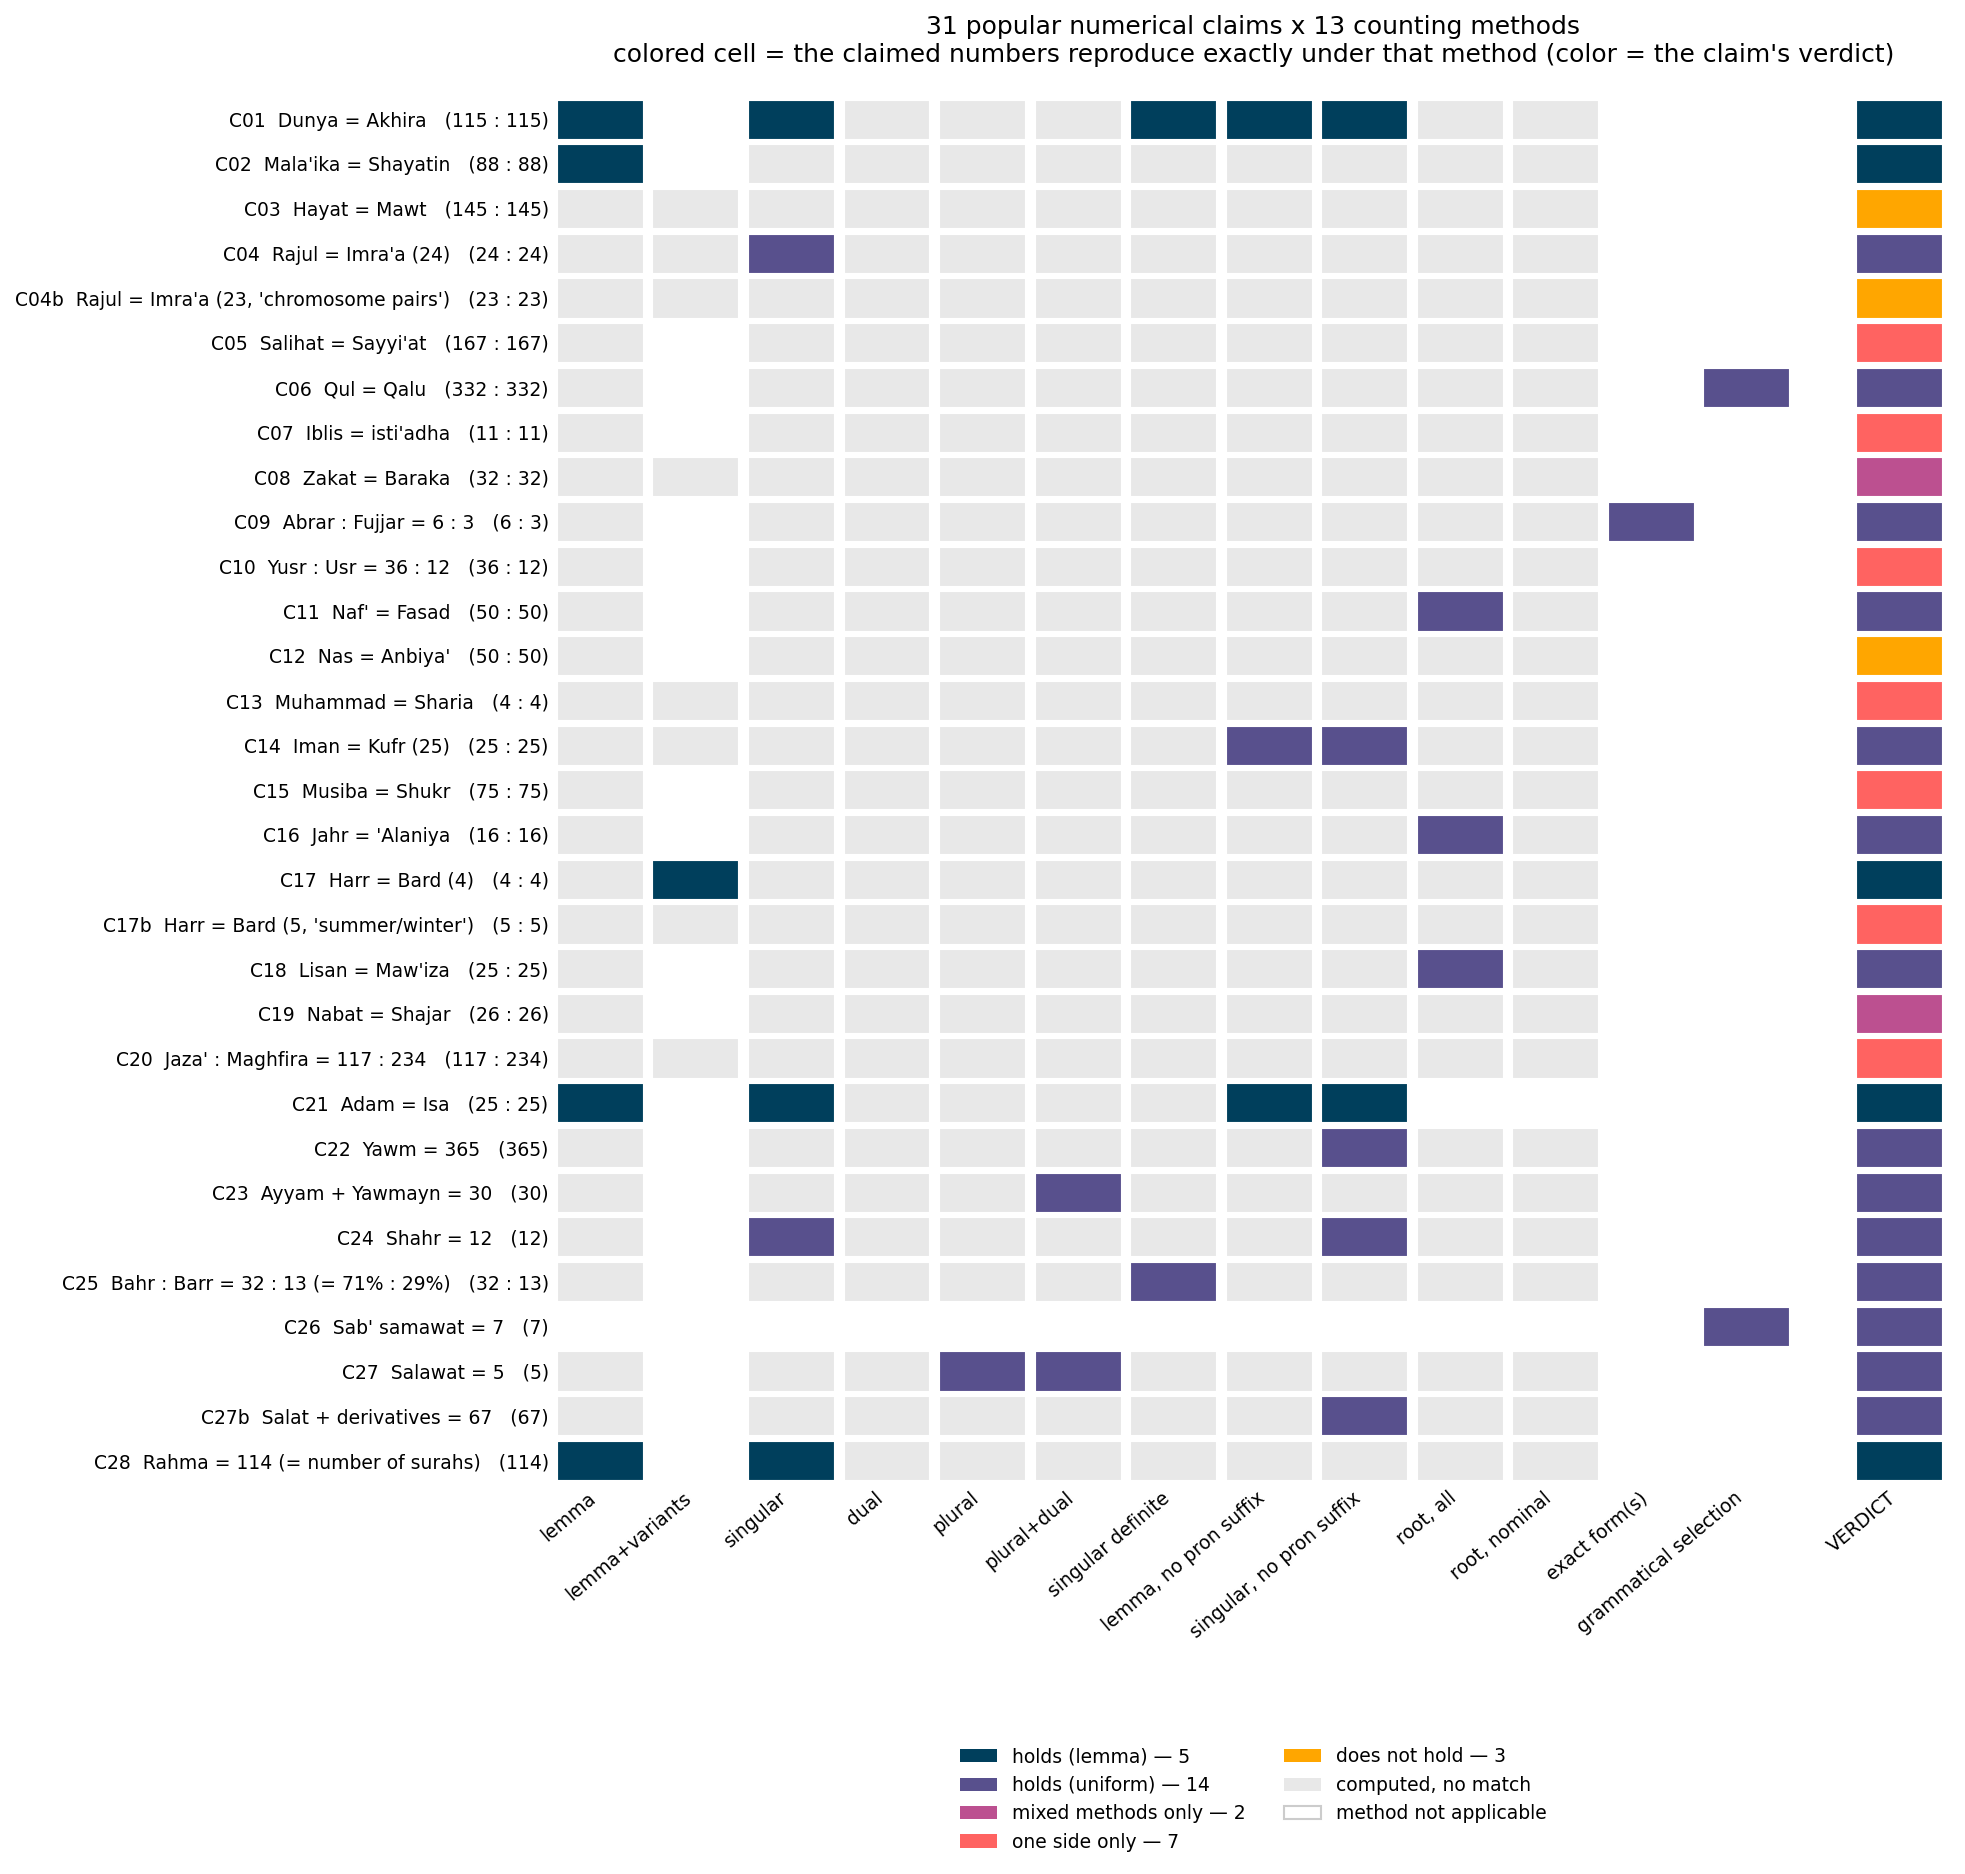

Saved output/claims_audit_matrix.png


In [14]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# verdict colors: learnui.design Data Color Picker palette (as in notebook 03's charts)
VCOLORS = {
    "holds (lemma)":      "#003f5c",
    "holds (uniform)":    "#58508d",
    "mixed methods only": "#bc5090",
    "one side only":      "#ff6361",
    "does not hold":      "#ffa600",
}
NO_MATCH, NA = "#e8e8e8", "#ffffff"

claim_ids = [c[0] for c in CLAIMS]
verd = summary.set_index("id")
mat_colors = np.empty((len(claim_ids), len(METHODS)), dtype=object)
g = audit_grid.set_index(["id", "method"])
for i, cid in enumerate(claim_ids):
    for j, m in enumerate(METHODS):
        if (cid, m) not in g.index:
            mat_colors[i, j] = NA
        elif g.loc[(cid, m), "match"]:
            mat_colors[i, j] = VCOLORS[verd.loc[cid, "verdict"]]
        else:
            mat_colors[i, j] = NO_MATCH

fig, ax = plt.subplots(figsize=(12, 12))
for i in range(len(claim_ids)):
    for j in range(len(METHODS)):
        ax.add_patch(plt.Rectangle((j, len(claim_ids) - 1 - i), 0.92, 0.92,
                                   facecolor=mat_colors[i, j], edgecolor="white", lw=1.5))
# verdict swatch column on the right, so claims with no uniform match still show their verdict
vx = len(METHODS) + 0.6
for i, cid in enumerate(claim_ids):
    ax.add_patch(plt.Rectangle((vx, len(claim_ids) - 1 - i), 0.92, 0.92,
                               facecolor=VCOLORS[verd.loc[cid, "verdict"]],
                               edgecolor="white", lw=1.5))
ax.set_xlim(0, vx + 1); ax.set_ylim(0, len(claim_ids))
ax.set_xticks([j + 0.46 for j in range(len(METHODS))] + [vx + 0.46])
ax.set_xticklabels(METHODS + ["VERDICT"], rotation=40, ha="right", fontsize=9)
ylabels = [f"{c[0]}  {c[1]}   ({' : '.join(map(str, c[3]))})" for c in CLAIMS]
ax.set_yticks([len(claim_ids) - 1 - i + 0.46 for i in range(len(claim_ids))])
ax.set_yticklabels(ylabels, fontsize=9)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)

counts = summary.verdict.value_counts()
legend = [Patch(facecolor=c, label=f"{v} — {counts.get(v, 0)}") for v, c in VCOLORS.items()]
legend += [Patch(facecolor=NO_MATCH, label="computed, no match"),
           Patch(facecolor=NA, edgecolor="#cccccc", label="method not applicable")]
ax.legend(handles=legend, loc="upper center", bbox_to_anchor=(0.5, -0.18),
          ncol=2, frameon=False, fontsize=9)
ax.set_title("31 popular numerical claims x 13 counting methods\n"
             "colored cell = the claimed numbers reproduce exactly under that method "
             "(color = the claim's verdict)", fontsize=12, pad=16)
plt.savefig("../output/claims_audit_matrix.png", dpi=150, bbox_inches="tight")
plt.close()
from IPython.display import Image
display(Image("../output/claims_audit_matrix.png"))
print("Saved output/claims_audit_matrix.png")

## 8. Are the symmetries jointly consistent?

No single counting rule makes the claims hold *together*. The table below counts, for each
method, how many of the 31 claims would hold if that one method were applied across the
board. The best single method recovers 6 — and half of those are words with no plurals or
suffixed forms, which hold under nearly any method. The selections that rescue the remaining
claims are mutually inconsistent (visible in the matrix above: no solid vertical stripe).

In [15]:
per_method = (audit_grid[audit_grid.match].groupby("method").size()
              .sort_values(ascending=False).rename("claims that hold (of 31)"))
print(per_method.to_string())
assert per_method.max() == 6  # "singular, no pron suffix" — the best any single rule does

method
singular, no pron suffix    6
singular                    5
lemma                       4
lemma, no pron suffix       3
root, all                   3
grammatical selection       2
plural+dual                 2
singular definite           2
exact form(s)               1
lemma+variants              1
plural                      1


## 9. Occurrence index — every location any method counts

Same verifiability mechanism as `output/occurrences.csv` for the 38 words: one row per
occurrence that contributes to *any* counting method for *any* claim side (lemma, variants,
root, exact forms, and both words of the sabʿ samāwāt phrase), so every number in the audit
can be checked by hand and token-validated against the canonical text (README §4).
`basis` says which selections pull the row in.

In [16]:
frames = []
for key, side in S.items():
    bases = {}
    lm = side_mask(side)
    if lm is not None:
        for i in df.index[lm]:
            bases.setdefault(i, []).append("lemma")
        vm = side_mask(side, variants=True) & ~lm
        for i in df.index[vm]:
            bases.setdefault(i, []).append("variant")
    if side.get("root"):
        for i in df.index[df.ROOT == side["root"]]:
            bases.setdefault(i, []).append("root")
    if side.get("forms"):
        for i in df.index[df.form.isin(side["forms"])]:
            bases.setdefault(i, []).append("form")
    if key == "sab_samawat":
        sw = df[df.LEM.isin(["saboE", "saboEap"])][["chapter", "verse", "word"]].values.tolist()
        sky = set(map(tuple, df[df.LEM == "samaA^'"][["chapter", "verse", "word"]].values.tolist()))
        phrase_locs = set()
        for c, v, w in sw:
            for nb_w in (w + 1, w - 1):
                if (c, v, nb_w) in sky:
                    phrase_locs |= {(c, v, w), (c, v, nb_w)}
        for i in df.index[LOC.isin(phrase_locs)]:
            bases.setdefault(i, []).append("phrase")
    if not bases:
        continue
    sub = df.loc[sorted(bases)].copy()
    sub.insert(0, "side", key)
    sub["basis"] = ["+".join(bases[i]) for i in sorted(bases)]
    frames.append(sub)

claims_occ = pd.concat(frames)
claims_occ["location"] = (claims_occ.chapter.astype(str) + ":" +
                          claims_occ.verse.astype(str) + ":" + claims_occ.word.astype(str))
claims_occ["form_arabic"] = claims_occ.form.map(bw_to_arabic)
cols = ["side", "location", "form", "form_arabic", "LEM", "ROOT", "POS", "NUMBER", "PGN", "basis"]
claims_occ[cols].to_csv("../output/claims_occurrences.csv", index=False)
n_locs = claims_occ.location.nunique()
print(f"Saved output/claims_occurrences.csv ({len(claims_occ)} rows, {n_locs} unique locations)")

# the index must tie out with the audit grid for the headline methods
g2 = audit_grid.set_index(["id", "method"])
per_side_lemma = claims_occ[claims_occ.basis.str.contains("lemma")].groupby("side").size()
for cid, title, ar, claimed, side_keys, *_ in CLAIMS:
    for pos, k in enumerate(side_keys):
        if S[k].get("lemmas"):
            col = "count_a" if pos == 0 else "count_b"
            got = int(per_side_lemma.get(k, 0))
            want = int(g2.loc[(cid, "lemma"), col])
            assert got == want, (cid, k, got, want)
print("Occurrence index ties out with the audit grid's lemma column for every side.")

Saved output/claims_occurrences.csv (8793 rows, 7039 unique locations)
Occurrence index ties out with the audit grid's lemma column for every side.


## 10. Validation of the claims-audit words (closing the scope gap)

The claims audit initially carried a caveat: words outside the 38-word set were not validated
the way the 38 were. Both validation layers have now been extended to full coverage
(2026-06-11), removing the caveat:

**Token-level (canonical text).** `output/claims_occurrences.csv` (section 9) feeds the same
JQuranTree pipeline as the 38-word index: every location counted by *any* method of *any*
claim was reconstructed from the morphology file and compared, letter-skeleton against
letter-skeleton, with the Tanzil Uthmani text. Result: **7,806/7,806 unique locations match,
0 mismatches, 0 missing** (`validation/token_validation_report.txt`; this covers the union of
both occurrence indexes).

**Upstream revision (corpus.quran.com).** The 22 roots used by claims-audit words and not
already verified in notebook 03 §9 were fetched from the corpus website dictionary
(`qurandictionary.jsp?q=ROOT`) and compared — done outside this notebook so it has no network
dependency. **Every root total and every per-lemma count matched exactly** (~120 numbers):

```
SlH 180   Ew* 17   fjr 24   ysr 44   Esr 12   nfE 50   fsd 50   nws 241
nbA 160   $rE 5    Swb 77   $kr 75   jhr 16   Eln 16   lsn 25   wEZ 25
nbt 26    $jr 27   jzy 118  Slw 99   sbE 28   smw 381
```

Where the website merges parts of speech within a lemma, the merged figures agree with our
POS splits: fujjār 4 (N 3 + ADJ 1), yasīr 15 (N 5 + ADJ 10), shakūr 10 (ADJ 9 + N 1),
ṣāliḥ 65 (N 60 + ADJ 5), sabʿ 23 (N 22 + T 1), musamman 21 (N 16 + ADJ 5). The remaining
claims-audit roots (swA 167, gfr 234, Amn 879, kfr 525, qwl 1722, rHm 339, zkw 59, brk 32,
ywm 405, $hr 21, bHr 42, brr 32, Hrr 15, brd 5, Hyy 184, mwt 165, rjl 73, mrA 38, dnw 133,
Axr 250, mlk 206, $Tn 88, nsw 59, Ans 97) were already verified in notebook 03 §9.